In [9]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Data path from Tutorial 1
data_path = "/home/xdevos/Repositories/pyHi-M/traceratops/data/RUT"
dest_path = f"{data_path}/merged_output/dest"

# Input file from Tutorial 1
input_trace = f"{dest_path}/merged_traces.ecsv"

print(f"Input file: {input_trace}")
print(f"Output folder: {dest_path}")
print(f"")
!ls -lh {input_trace}

Input file: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/dest/merged_traces.ecsv
Output folder: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/dest

-rw-r--r-- 1 xdevos users 18M 19 mars  09:46 /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/dest/merged_traces.ecsv


# Tutorial 2: Quality Control Analysis of Merged Chromatin Traces

Before filtering or downstream analysis, assess your data quality through comprehensive statistical analysis.

`trace_analyzer` computes:
- **Trace Statistics**: Distribution of barcode counts per trace
- **Barcode Detection**: How reliably each barcode is detected (bootstrap analysis)
- **Neighbor Distances**: Spacing between consecutive barcodes (ΔX, ΔY, ΔZ)
- **Barcode Frequencies**: How often individual barcodes appear

These metrics guide filtering decisions in Tutorial 3.

## Step 1: Run Comprehensive Quality Control Analysis

In [10]:
# Run trace_analyzer for detailed quality metrics
!trace_analyzer --input {input_trace} -F {dest_path}

print("\n✓ Quality control analysis complete")


1 trace files to process= /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/dest/merged_traces.ecsv
$ Importing table from pyHiM format
Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/dest/merged_traces.ecsv
> Analyzing traces for /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/dest/merged_traces.ecsv
$ Number of spots in trace file: 117211
$ Calculating overall barcode detection across 26591 traces...
$ Exporting barcode detection plot to: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/dest/merged_traces_barcode_detection.png
$ Saved neighbor distances plot: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/dest/merged_traces_first_neighbor_distances.png
$ Mean distances between neighboring barcodes: X=-0.000, Y=-0.000, Z=0.002
$ Calculating barcode stats...
100%|███████████████████████████████████| 26591/26591 [00:03<00:00, 7060.31it/s]
$ Exporting relati

## Step 2: Barcode Detection Efficiency

This plot shows how often each individual barcode is detected across all traces. Each barcode is represented by a **violin plot** (bootstrap distribution with 1000 iterations), which shows:

- **Height of the violin**: Range of detection frequencies (0-100%)
- **Median line**: Most common detection frequency
- **Shape**: Distribution shape indicates consistency

**Interpretation:**
- Narrow violin = reliable barcode (consistent detection)
- Wide violin = unreliable barcode (variable detection)
- Barcodes near 0% or 100% = may be problematic

▶ Barcode Detection Efficiency (with bootstrap 1000x):


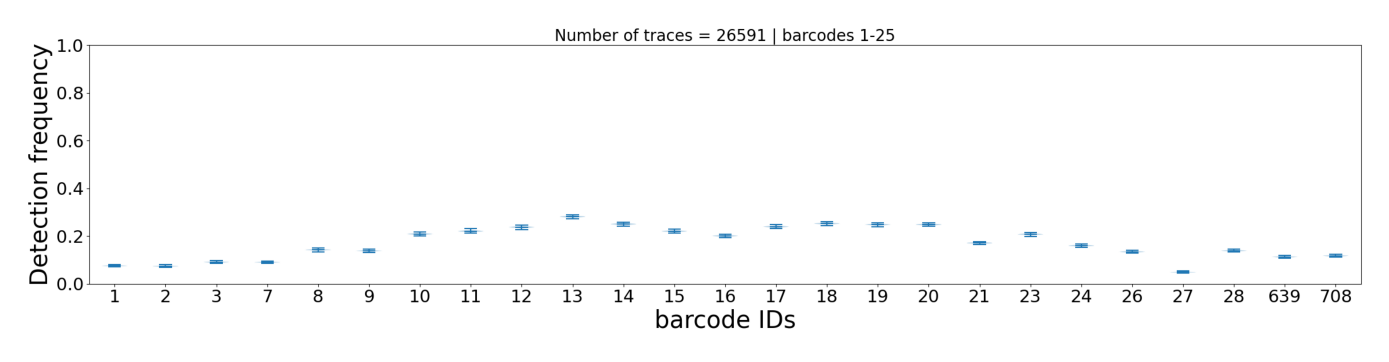

In [11]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plot_file = f"{dest_path}/merged_traces_barcode_detection.png"
if os.path.exists(plot_file):
    print("▶ Barcode Detection Efficiency (with bootstrap 1000x):")
    img = mpimg.imread(plot_file)
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.imshow(img)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f"✗ Plot not found at {plot_file}")

## Step 3: Neighbor Distance Distribution

This plot shows distances between **consecutive barcodes** (barcode_i+1 - barcode_i) for all traces. Three distributions are shown:

- **ΔX (blue)**: Distance in X dimension (genomic/spatial coordinate)
- **ΔY (green)**: Distance in Y dimension
- **ΔZ (red)**: Distance in Z dimension (focus/optical)

Each histogram displays:
- Mean and standard deviation of that dimension
- Distribution shape (indicates consistency of spacing)

**Interpretation:**
- Normal distribution (bell-shaped) = uniform spacing between barcodes
- Large spread or multiple peaks = inconsistent spacing or detection issues
- ΔZ much larger than others = potential focusing problems

▶ Neighbor Distance Distribution (consecutive barcodes):


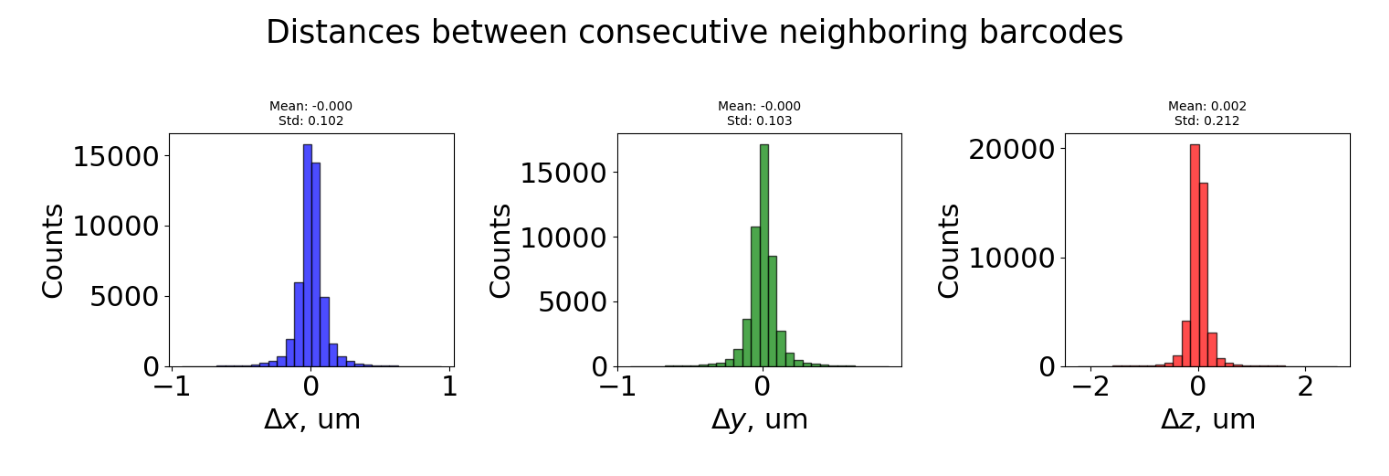

In [12]:
plot_file = f"{dest_path}/merged_traces_first_neighbor_distances.png"
if os.path.exists(plot_file):
    print("▶ Neighbor Distance Distribution (consecutive barcodes):")
    img = mpimg.imread(plot_file)
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.imshow(img)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f"✗ Plot not found at {plot_file}")

## Step 4: Barcode Repetition Patterns

This plot shows how often individual barcodes are **repeated** (duplicated) within single traces. Each violin shows the distribution of repetition counts for that barcode:

- **X-axis**: Barcode identifiers
- **Y-axis**: Number of times each barcode appears per trace (repetition count)

**Interpretation:**
- Near 1 = barcode appears once per trace (good, expected for unique barcodes)
- Toward 2+ = barcode frequently repeats within traces (indicates duplication/artifacts)
- Wide = inconsistent repetition patterns (may indicate detection noise or genomic repeats)

**Key insight:** High repetition values may indicate:
- Optical/detection artifacts (same barcode detected twice in same trace)
- Genomic repeats (same barcode at multiple genomic positions)
- These duplicates are often filtered in Tutorial 4

▶ Relative Barcode Frequencies:


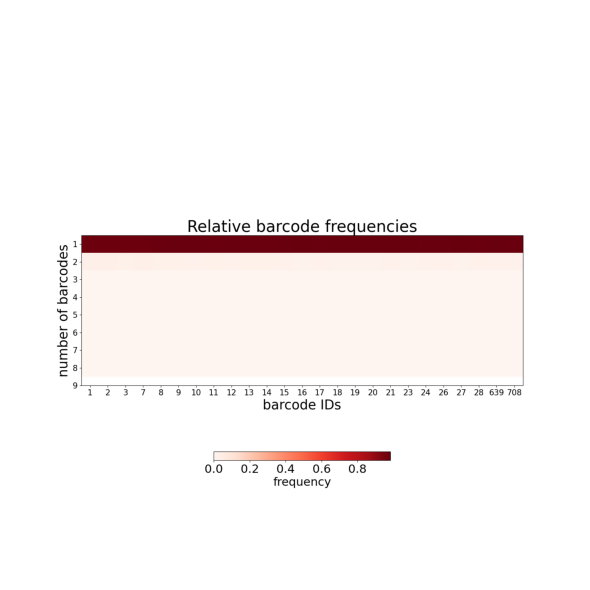

In [14]:
plot_file = f"{dest_path}/merged_traces_relative_barcode_frequencies.png"
if os.path.exists(plot_file):
    print("▶ Relative Barcode Frequencies:")
    img = mpimg.imread(plot_file)
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.imshow(img)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f"✗ Plot not found at {plot_file}")

## Step 5: Trace Statistics Summary

This panel shows three related distributions of counts across all traces:

- **Left histogram (N_barcodes)**: Number of barcode detections per trace
- **Middle histogram (N_unique_barcodes)**: Number of distinct barcodes per trace
- **Right histogram (N_repeated_barcodes)**: Number of barcodes appearing more than once per trace

Each histogram displays:
- The number of traces analyzed (n)
- The median value of that metric

**Interpretation:**
- N_barcodes peak position indicates trace completeness
- Narrow histograms = consistent quality across traces
- Broad histograms = variable trace quality
- N_repeated_barcodes indicates optical/detection artifacts

▶ Trace Statistics Summary (3 distributions):


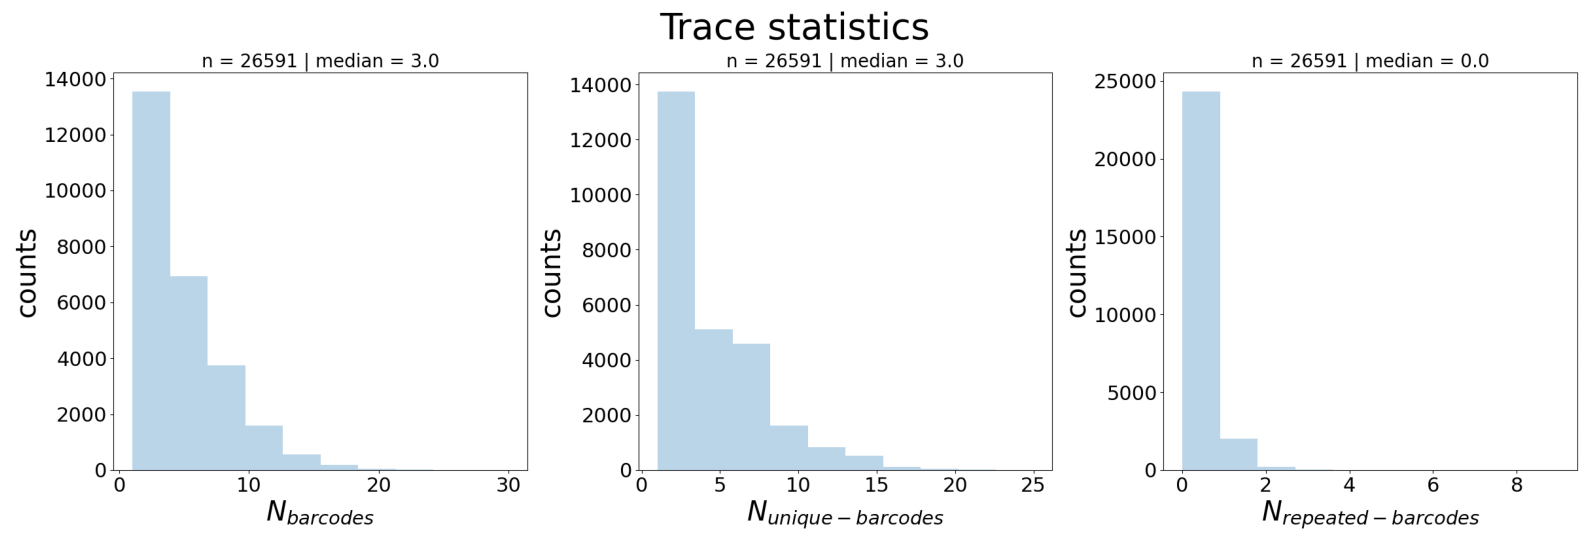

In [15]:
plot_file = f"{dest_path}/merged_traces_trace_statistics.png"
if os.path.exists(plot_file):
    print("▶ Trace Statistics Summary (3 distributions):")
    img = mpimg.imread(plot_file)
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.imshow(img)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f"✗ Plot not found at {plot_file}")

## Step 6: Using QC Insights for Filtering

From the QC plots above, you can extract key metrics to guide filtering decisions in Tutorial 3:

### From Trace Statistics:
- **N_barcodes median value** → Set `--n_barcodes` filter threshold slightly below this value
- **Distribution width** → Narrow distribution = dataset is consistent; wide = variable quality
- **N_repeated_barcodes** → High values indicate duplicate handling may be needed (Tutorial 4)

### From Barcode Detection:
- **Violin width** → Narrow violins = use those barcodes confidently; wide = may exclude from analysis
- **Median detection** → Barcodes with low medians (<50%) may be problematic

### From Neighbor Distances:
- **ΔX/ΔY distribution** → Shape indicates genomic/spatial consistency
- **ΔZ relative to others** → If much larger, may indicate focusing issues

### From Barcode Repetition:
- **Violins centered on 1** → These barcodes appear once per trace (ideal)
- **Violins spreading to 2+** → Many traces have barcode duplicates (may need filtering)
- **Wide spread** → Inconsistent repetition patterns (consider excluding problematic barcodes)

## Step 7: Key Metrics Summary

Record these observations from your QC plots:

| Metric | What to Look For | Decision Impact |
|--------|------------------|------------------|
| N_barcodes median | Peak position | Sets `--n_barcodes` threshold |
| N_barcodes width | Distribution shape | Indicates data consistency |
| Barcode detection | Violin width | Identifies unreliable barcodes |
| ΔZ distribution | Center and spread | May reveal focusing issues |
| Barcode repetition | Violin spread near 1 vs 2+ | Identifies duplicated barcodes to filter |
| Repeated barcodes | Count and frequency | May need duplicate filtering |

Use these observations to determine filtering strategy for the next tutorial.

## Summary

Quality control revealed important characteristics of your merged dataset:

- **Trace completeness** - How many barcodes detected per trace
- **Barcode reliability** - Detection consistency for each barcode
- **Spatial resolution** - Spacing characteristics (ΔX, ΔY, ΔZ)
- **Data consistency** - Variation across individual traces and ROIs

**Next:** Tutorial 3 - Apply Direct Threshold Filtering using insights from these QC metrics